Projeto final - Módulo 1 - SCTEC

# Fase 1: Análise Exploratória (EDA)

Apresente as dimensões do dataset (número de linhas e colunas), os tipos de dados das variáveis e o resumo estatístico descritivo das colunas numéricas via método “.describe()”.

Plote, no mínimo, 3 gráficos analíticos bem fundamentados utilizando bibliotecas como Matplotlib ou Seaborn (Ex: histograma de distribuição das variáveis preditoras, gráfico de barras comprovando a taxa de desbalanceamento da variável alvo e um mapa de calor com a correlação de Pearson entre as variáveis).

Insira uma célula de texto analisando os valores numéricos e os padrões identificados nos gráficos, explicitando como eles direcionam a estratégia de modelagem.


## Antes de começar, selecionar o Kernel ".venv" e configurar o notebook

In [2]:
# Configuração inicial de todos os notebooks (ver o src.config)

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração do visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("\n=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===")


=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===


# Carregando os dados do dataset

In [4]:
# Leitura do arquivo

df = pd.read_csv("../data/raw/manutencao_preditiva.csv", sep=",")
print("\n --- ARQUIVO LIDO COM SUCESSO ---")
df.head()



 --- ARQUIVO LIDO COM SUCESSO ---


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [11]:
# Apresentar as dimenções do dataset

print("\n --- DIMENSÕES DO DATA SET ---")
print(f"NÚMERO DE LINHAS: {df.shape[0]}")
print(f"NÚMERO DE COLUNAS: {df.shape[1]}")

print("\n --- TIPO DE DADOS DAS VARIÁVEIS ---")
print(df.info())

print("\n --- RESUMO ESTATÍSTICO DESCRITIVO ---")
df.describe()



 --- DIMENSÕES DO DATA SET ---
NÚMERO DE LINHAS: 10000
NÚMERO DE COLUNAS: 14

 --- TIPO DE DADOS DAS VARIÁVEIS ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                1

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# Análise gráfica dos dados ainda sem tratamento

Representaçãoes gráficas podem ser utilizadas para compreender como os dados se comportam. 
E, como objetivo deste projeto é prever quebras mecânicas nos equipamentos para evitar paradas na linha de produção, os gráficos de diagnóstico inicial também podem focar no comportamento de opereração normal versus o comportamento que antecede a quebra.
Nesta análise exploratória utilizamos estas duas abordagens.


In [14]:
# Para os gráficos serem salvos na pasta "outputs"

def salvar_grafico(nome_arquivo, etapa="01_eda", output_base_dir="../outputs/graficos"): # cria a subpasta para a etapa atual e exporta o gráfico gerado
    output_dir = os.path.join(output_base_dir, etapa)
    os.makedirs(output_dir, exist_ok=True) # cria o caminho dinâmico

    caminho_completo = os.path.join(output_dir, f"{nome_arquivo}.png") # define o caminho final do arquivo de imagem

    plt.savefig(caminho_completo, dpi=300, bbox_inches="tight")
    print(f"Grafico salvo em:{caminho_completo}") #salva o grafico atual

Grafico salvo em:../outputs/graficos\01_eda\01_distribuição das variáveis.png


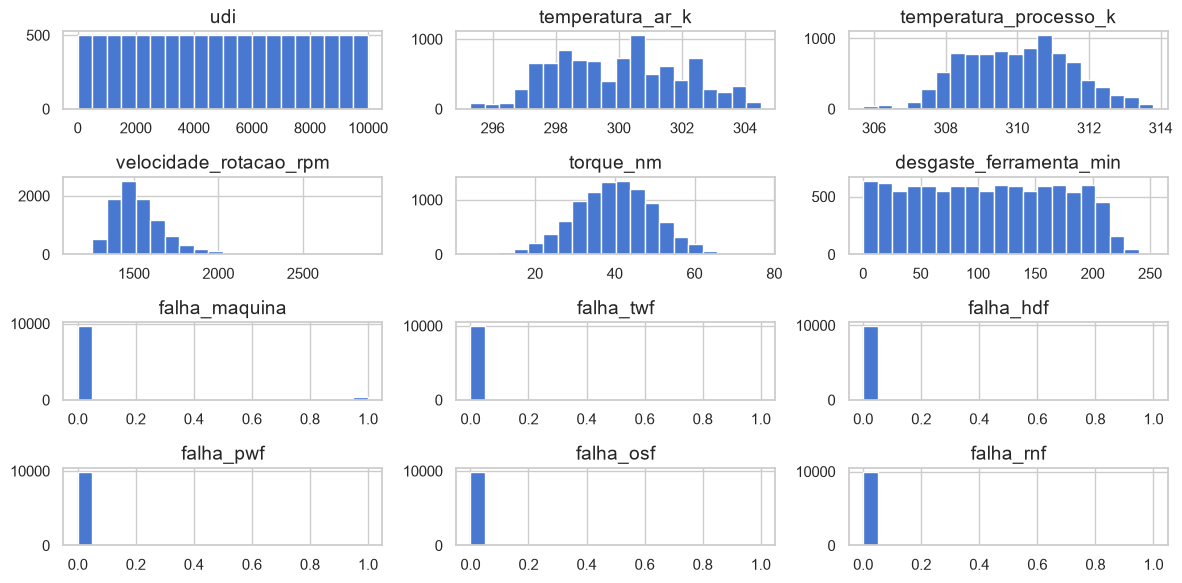

In [19]:
# Histograma para análise da distribuição das variáveis preditoras

df.hist(bins=20)

plt.tight_layout()
salvar_grafico("01_distribuição das variáveis")
plt.show()


Grafico salvo em:../outputs/graficos\01_eda\01_desbalanceamento_alvo.png


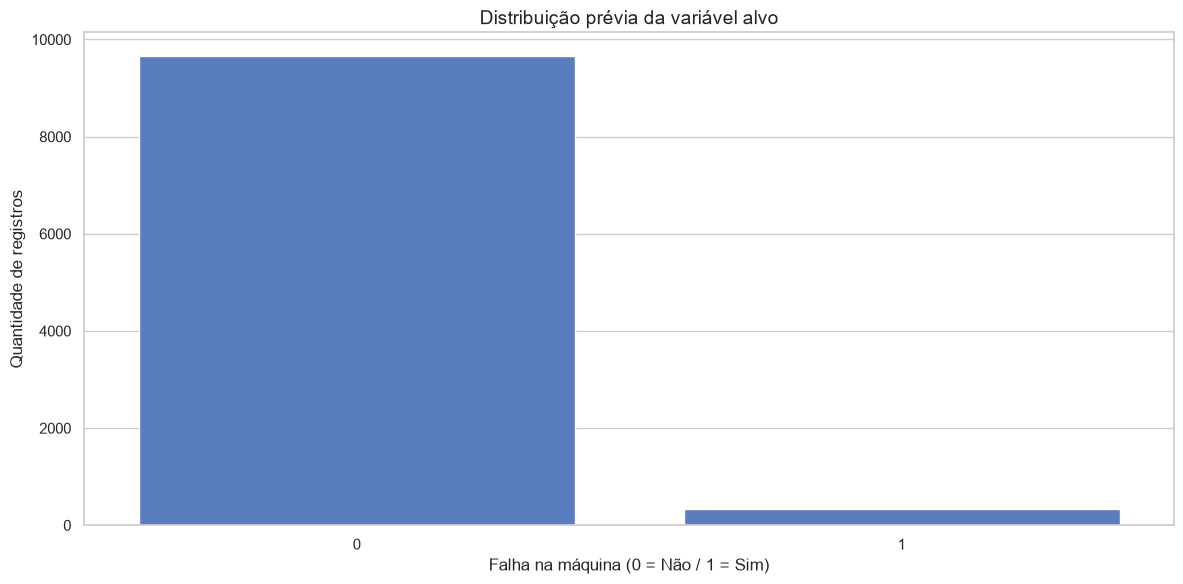

In [20]:
# Gráfico de barras para análise do desbalanceamento da variável alvo

sns.countplot(data=df,x='falha_maquina')
plt.title("Distribuição prévia da variável alvo")
plt.xlabel("Falha na máquina (0 = Não / 1 = Sim)")
plt.ylabel(("Quantidade de registros"))

plt.tight_layout()
salvar_grafico("01_desbalanceamento_alvo")
plt.show()

Grafico salvo em:../outputs/graficos\01_eda\01_mapa_de_calor.png


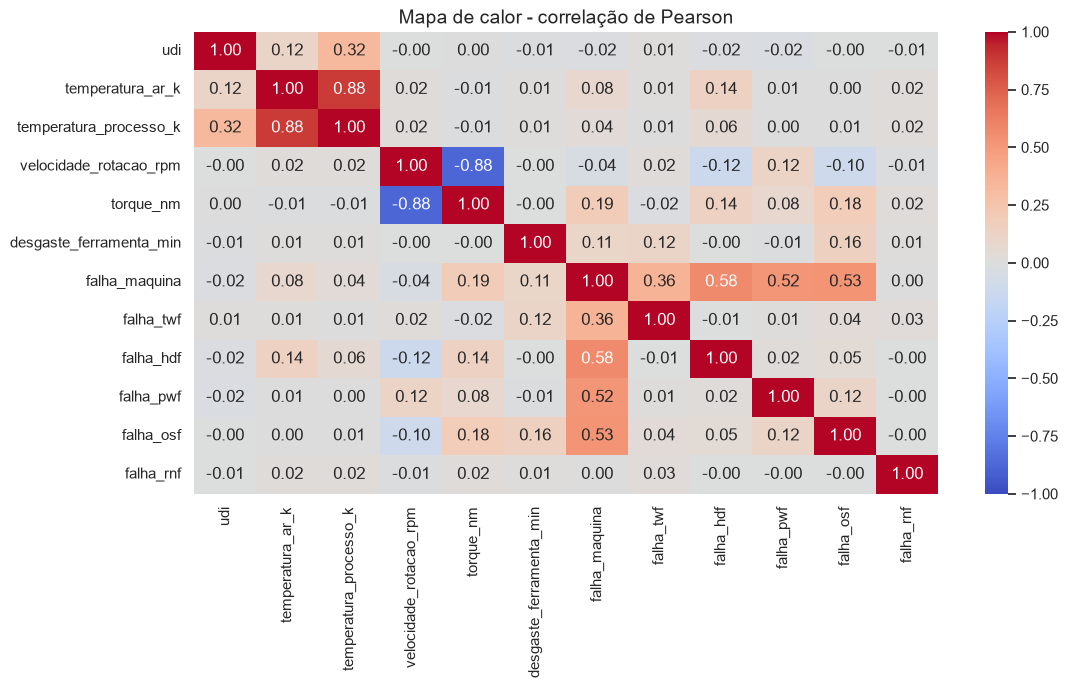

In [23]:
# Mapa de calor: diagnóstico de correlação das variáveis
# O mapa de calor é o gráfico que mostra imediatamente a correlação entre as falhas e as variáveis, além de ignorar valores ausentes e direcionar a limpeza dos outliers.

# Cálculo da matriz de correlação de Pearson
matriz_correlacao = df.corr(method='pearson', numeric_only=True)

# Gráfico
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Mapa de calor - correlação de Pearson")
salvar_grafico("01_mapa_de_calor")
plt.show()

Análise:

Observando o conjunto de histogramas de distribuição das variáveis nota-se que as variáveis preditoras contínuas (temperaturas, torque e velocidade) apresentam uma distribuição em forma de sino, bem próxima da normal, com dados bem distribuídos. Já atributos como udi e desgaste_ferramenta_min possuem uma distribuição uniforme, com comportamento de plano. E, as variáveis de tipo de falha estão concentradas em apenas uma barra, mostrando desbalanceamento. No entanto os valores numéricos dos eixos são muito distantes entre si, indicando a necessidade de futura aplicação de padronização de escalas para equilibrar o peso dessas variáveis no modelo. 
O gráfico de barras da variável alvo comprova um desbalanceamento intenso, com uma quantidade de falhas muito pequena dentro do conjunto de dados. Este comportamento evidencia que o modelo não pode ser treinado diretamente, sendo obrigatória a aplicação de técnicas de balanceamento dos dados.
Pelo mapa de calor é possível observar uma correlação muito forte, quase linear, entre as temperaturas do ar e de processo (0.88) e entre a velocidade de rotação e o torque (-0.88). O sinal negativo na correlação entre a velocidade de rotação e o torque indica que a correlação é inversa, ou seja, quando aumenta a velocidade de rotação, reduz-se o torque, um comportamento esperado na mecânica. Já para a temperatura, a correlação é positiva, indicando que quando o ar está mais aquecido, o processo também apresenta temperaturas mais elevadas.
Desconsiderando as variáveis que indicam o tipo de falha, é possível observar que o torque e o desgaste da ferramenta são as variáveis com maior correlação com a variável de falha. Apesar disso, os valores são muito baixos, indicando que não existe uma correlação linear direta e simples. A causa das quebras deve ser multifatorial. O histograma das variáveis com maiores correlações vai ajudar a entender o comportamento físico das máquinas através da distribuição dos dados com falha e em condições sem falha.


Grafico salvo em:../outputs/graficos\01_eda\01_histogramas_torque_desgaste.png


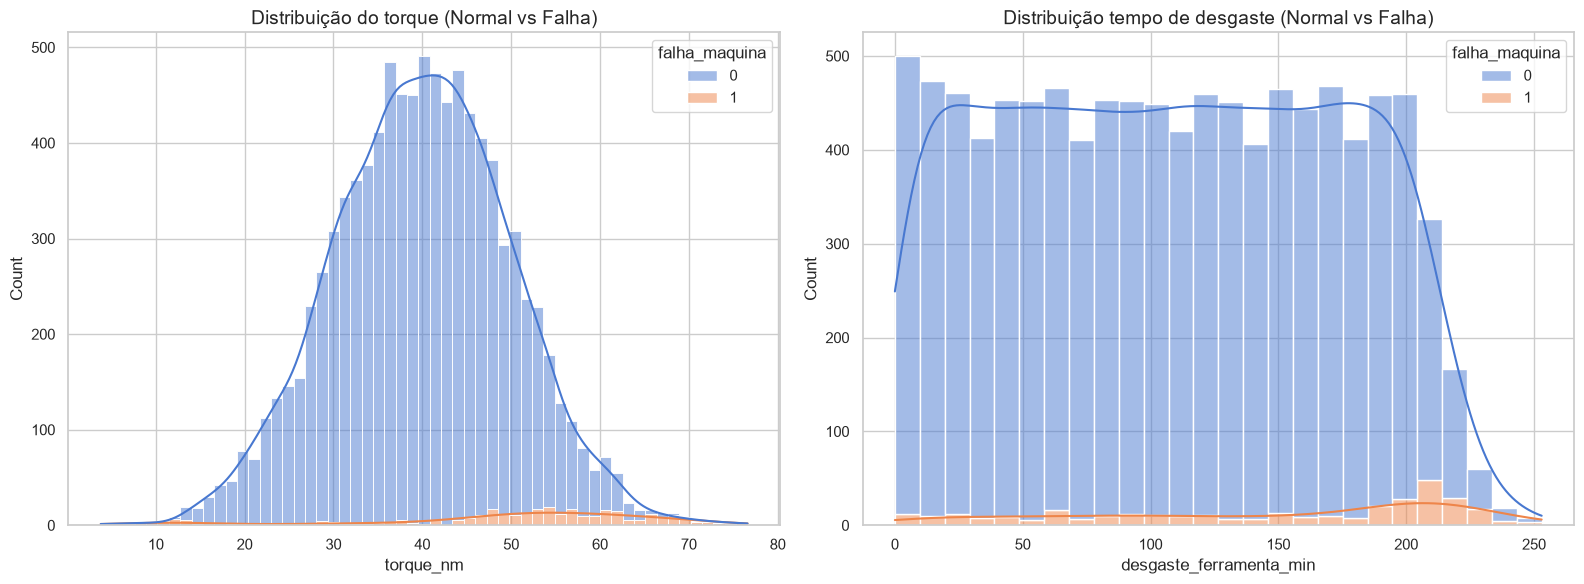

In [24]:
# Histogramas das variáveis com maiores correlações com as falhas

fig, axes = plt.subplots(1, 2, figsize=(16,6)) # para os gráficos sairem lado a lado

# Histograma do torque
sns.histplot(data=df, x='torque_nm', hue='falha_maquina', kde=True, ax=axes[0], multiple="stack") # o hue faz o histograma mostrar em cores diferentes quando há (1) e quando não há falha (0)
axes [0].set_title('Distribuição do torque (Normal vs Falha)')

# Histograma do desgaste da ferramenta
sns.histplot(data=df, x='desgaste_ferramenta_min', hue='falha_maquina', kde=True, ax=axes[1], multiple="stack") 
axes [1].set_title('Distribuição tempo de desgaste (Normal vs Falha)')

plt.tight_layout()
salvar_grafico("01_histogramas_torque_desgaste")
plt.show()


Análise:

Pelo histograma do torque é possível observar que as falhas começam a partir de 42Nm. Abaixo disso, as máquina operam em segurança e acima, os equipamentos estão mais vulneráveis a quebra por sobrecarga.
Já o histograma do desgaste da ferramenta mostra que existem falhas desde o minuto zero, mas com um pico entre 190 e 240 minutos, que indica o fim da vida útil da ferramenta por desgaste natural (fadiga).
Para comparar a média do tempo de desgaste da ferramenta para as condições de operação normal e com falha, foi gerado um gráfico de barras:

Grafico salvo em:../outputs/graficos\01_eda\01_tempo_medio_desgate.png


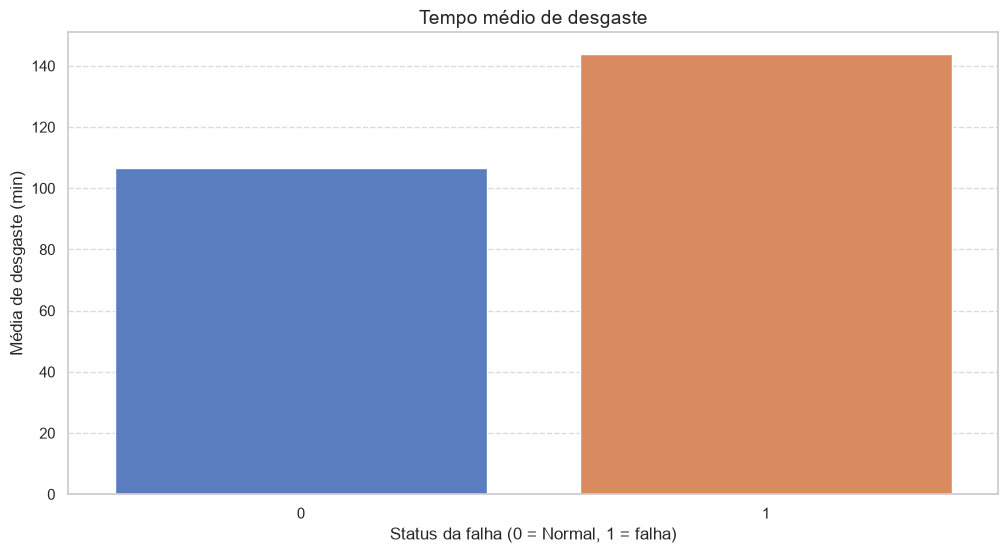

In [25]:
# Gráfico de barras para o tempo médio de operação normal e de falha

sns.barplot(data=df, x='falha_maquina', y='desgaste_ferramenta_min', palette='muted', hue='falha_maquina', legend=False, errorbar=None)

plt.title("Tempo médio de desgaste")
plt.xlabel('Status da falha (0 = Normal, 1 = falha)')
plt.ylabel('Média de desgaste (min)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
salvar_grafico("01_tempo_medio_desgate")
plt.show()

Análise: 

A média de aproximadamente 100 minutos para a operação normal e de 140 minutos para a operação com falha mostra que o desgaste acumulado aumetna a chance de falha. No entanto, se as quebras acontececem somente por desgaste avançado, a média da barra com falha deveria ser mais alta, perto de 200 minutos, que é o pico mostrado no histograma. A média do tempo de falha por desgaste está sendo afetada pelas quebras prematuras, que aparecem desde o tempo zero no histograma.